# Collecting simulated cavity data

Here we are interested in getting cavity data that exhibits static ponderomotive instability.

In [1]:
import os
import sys

cur_dir = os.getcwd()
example_dir = os.path.abspath(os.path.join(cur_dir, '..'))
sys.path.append(example_dir)
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

data_dir = '../../../data/regimes/cavity_fold'

import numpy as np
import matplotlib.pyplot as plt

import care

import util_data

### Instantiate cavity resonance simulator

In [2]:
# --! specify cavity parameters --!

parser = care.create_args_parser()

args = parser.parse_args(
    args=[
        '-fg', '1.3e9',                   # operating frequency, Hz
        '-ig', '0.016',                   # forward power equivalent current, A
        '-og', '-471.0',                  # offset from operating frequency, Hz

        '-rc', '1036',                    # R over Q of cavity, Ohm
        '-qc', '3e6',                     # loaded quality factor of cavity, unitless

        '-ga', '12e6',                    # amplifier gain

        '-fm', '280, 341, 460, 487, 618', # frequency of mechanical modes
        '-qm', '10, 20, 30, 20, 80',      # quality of mechanical modes
        '-km', '2, 0.8, 2, 0.6, 0.2',     # coupling of mechanical modes

        '-ts', '1e-6',                    # time step, s
        '-es', '{                 \
            "0":   "rf_on"        \
        }',
    ]
)

In [3]:
# --! simulator, helping functions and parameters --!

sim = care.simulator(args)              # cavity simulator

sim_t = 0.1                             # simulation time, s
sim_nsample = int(sim_t / args.step_t)  # number of simulation steps
sim_o_downsample = 50                   # downsampling factor for simulated signals

# --! specify initial conditions (ics) as a list of initial cavity voltages
ics = [
    0.0   + 1j * 0.0,
    0.0   + 1j * 1.2e6,
    2e6   + 1j * 1e6,
    2.5e6 + 1j * 1e6,
    2.5e6 + 1j * 1.5e6,
    3e6   + 1j * 1.55e6,
    3e6   + 1j * 1e6,
    3e6   + 1j * 1.59e6
]

def run_sim(sim, sim_nsample, ic, downsample=50):
    vc  = np.zeros(sim_nsample, dtype=complex)
    dc  = np.zeros(sim_nsample)

    sim.reset(ic)

    # --! step through cavity simulator
    for i in range(sim_nsample):
        vc[i], dc[i] = sim.step()

    # --! convert simulated signals
    vc = abs(vc) * 1e-6
    dc = dc / 2 / np.pi

    # --! downsample simulated signals
    vc = vc[::downsample]
    dc = dc[::downsample]

    # --! reshape 1d arrays into column vectors
    vc = vc.reshape(-1, 1)
    dc = dc.reshape(-1, 1)

    return vc, dc

def plot_result(vc, dc, sim_nsample, dt, downsample):

    t = np.arange(sim_nsample) * dt
    t = t[::downsample]

    plt.figure(figsize=(6, 6))

    plt.subplot(2,1,1)
    plt.plot(t, vc)
    plt.xlabel('Time (s)')
    plt.ylabel('Cavity voltage (MV)')

    plt.subplot(2,1,2)
    plt.plot(t, dc)
    plt.xlabel('Time (s)')
    plt.ylabel('Detuning (Hz)')

    plt.tight_layout()
    plt.show()

def plot_phasespace(vcs, dcs):

    plt.figure(figsize=(4, 4))

    for vc, dc in zip(vcs, dcs):
        plt.plot(dc, vc)
    plt.plot([min(dcs[0]), max(dcs[0])], [0, 0], linestyle='dashed', color='gray')
    plt.xlabel('Detuning (Hz)')
    plt.ylabel('Cavity voltage (MV)')

    plt.tight_layout()
    plt.show()

### Run simulation

In [4]:
# --! simulation loop to collect data --!

# --! empty lists for cavity voltage and detuning trajectories
vcs = []
dcs = []

# --! simulate trajectories
for ic in ics:
    vc, dc = run_sim(sim, sim_nsample, ic, downsample=sim_o_downsample)

    vcs.append(vc)
    dcs.append(dc)

### Display results

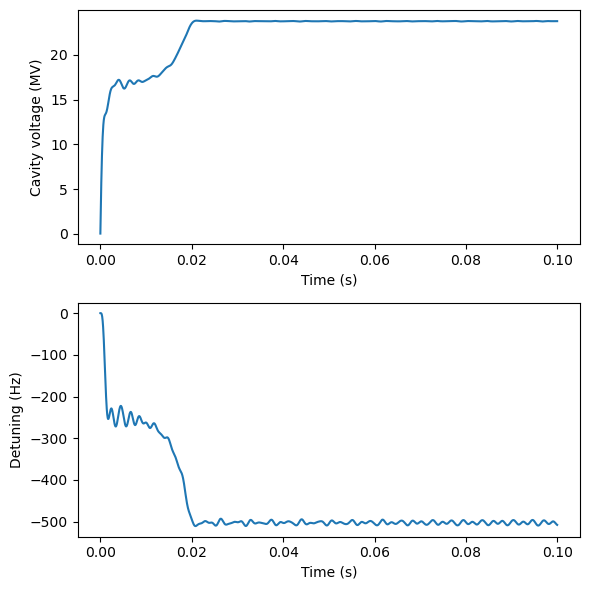

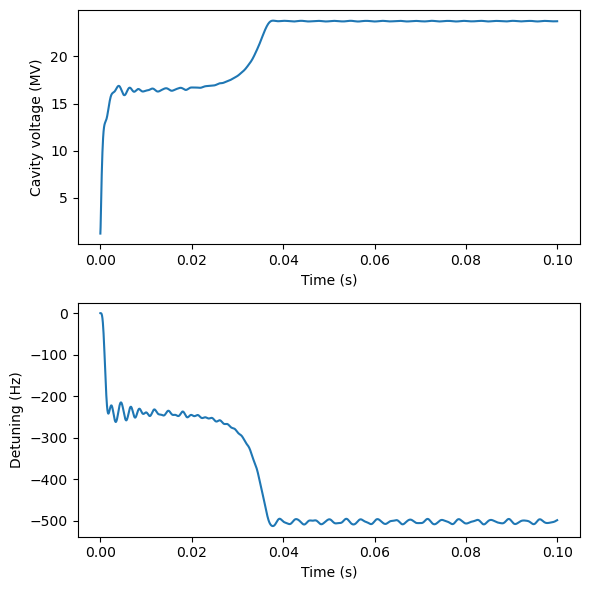

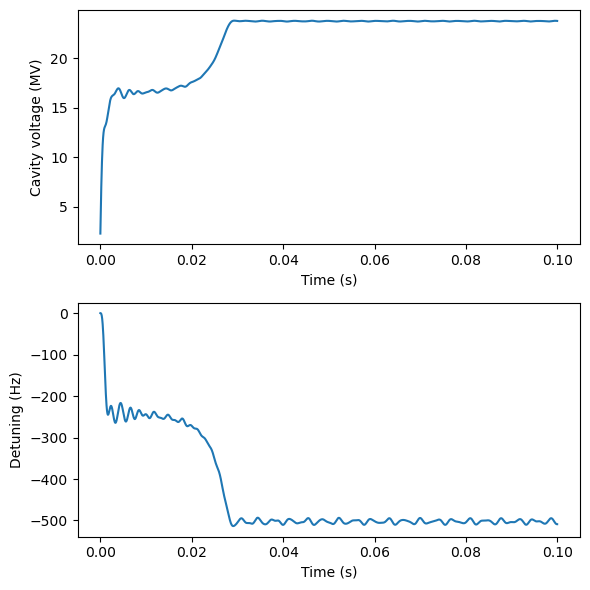

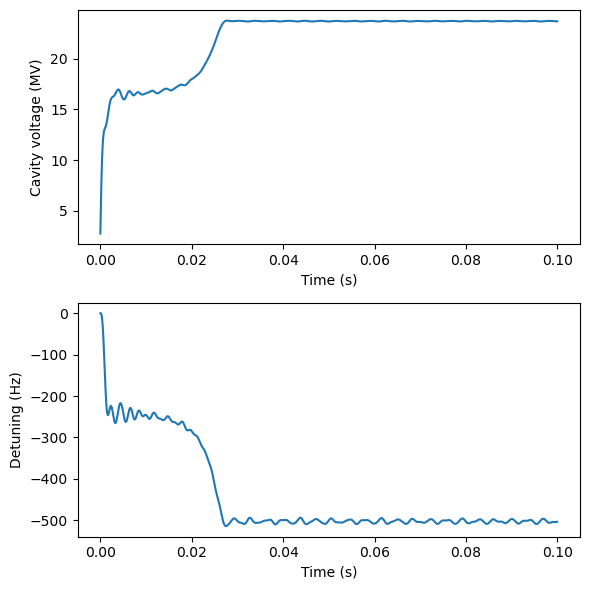

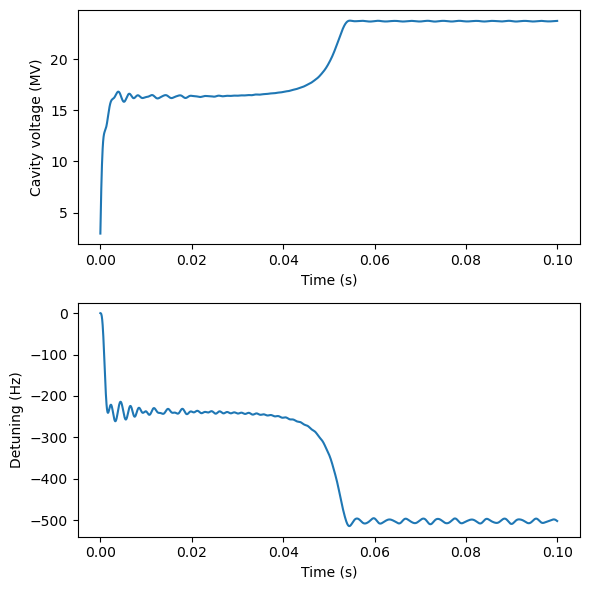

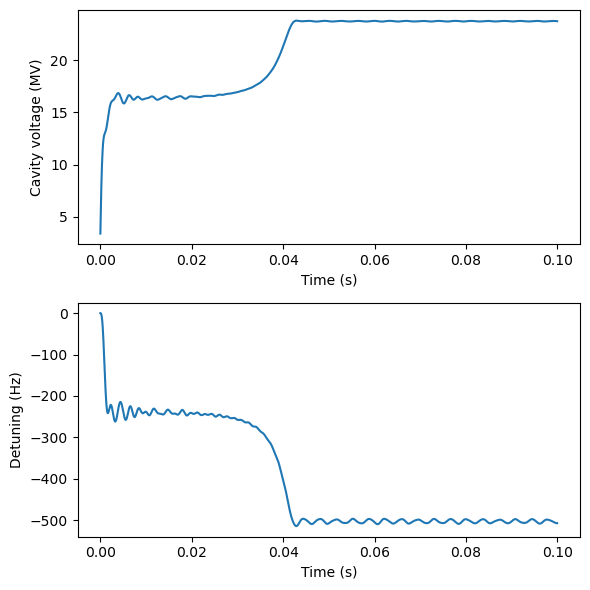

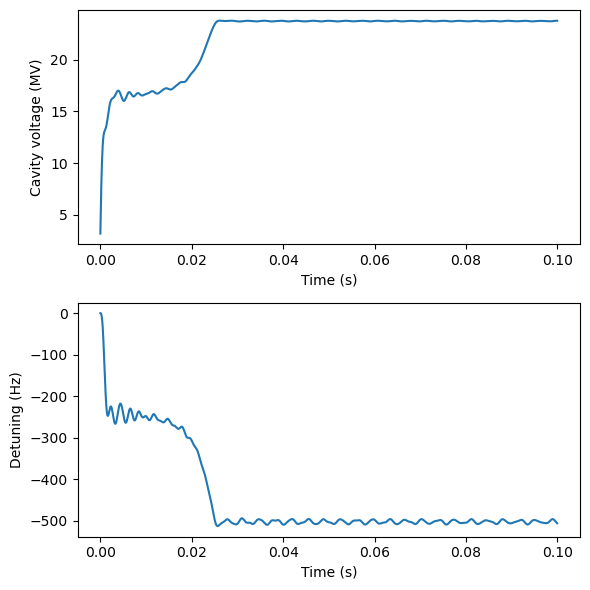

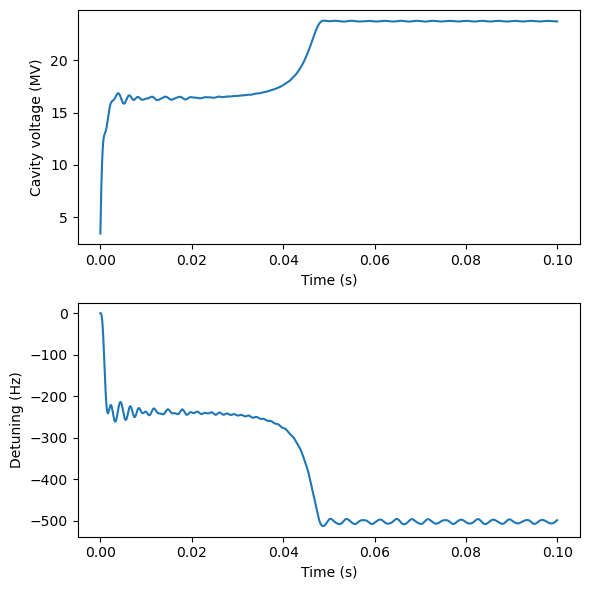

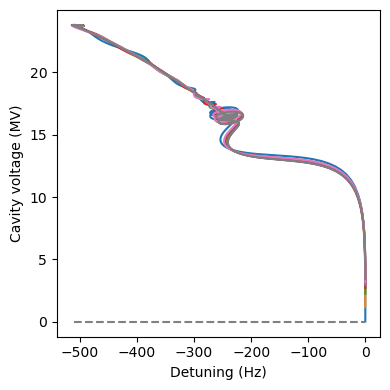

In [5]:
# --! display results --!

for vc, dc in zip(vcs, dcs):
    plot_result(vc, dc, sim_nsample, args.step_t, downsample=sim_o_downsample)

plot_phasespace(vcs, dcs)

### Process data into windows

In [6]:
def extract_windows(data, back_nsample, fore_nsample):

    windows = []

    data_nsample = data.shape[1]
    for d in data:
        for i in range(data_nsample):
            window_start = i - back_nsample
            window_end = i + fore_nsample
            if window_start >= 0 and window_end <= data_nsample:
                window = d[window_start:window_end, :]
                windows.append(window)

    return np.stack(windows)

vcs = np.stack(vcs)
dcs = np.stack(dcs)
data = np.concatenate([vcs, dcs], axis=-1)
print(f'inf > simulated data shape is {data.shape}')

fore_nsample = 24
back_nsample = 2 * fore_nsample
windows = extract_windows(data, back_nsample, fore_nsample)
print(f'inf > extracted windows shape is {windows.shape}')


inf > simulated data shape is (8, 2000, 2)
inf > extracted windows shape is (15432, 72, 2)


### Save data

In [7]:
datasaved = True

if datasaved:
    util_data.write_datafile(f'{data_dir}/windows', windows)
    print(f'inf > extracted windows saved')

inf > extracted windows saved
